# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ku-ro-wa/flyrank-ml-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
# Setup
from google.colab import userdata
import duckdb

HF_TOKEN = userdata.get('HF_TOKEN')

con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN {HF_TOKEN})")
rel = "hf://datasets/FlyRank/internship-warehouse"

# Check schema
con.sql(f"DESCRIBE SELECT * FROM read_parquet('{rel}/fact_content_daily_performance/**/*.parquet') LIMIT 0").show()

# Basic count
con.sql(f"""
    SELECT COUNT(*) AS n_rows
    FROM read_parquet('{rel}/fact_content_daily_performance/**/*.parquet')
""").show()

┌────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│    column_name     │ column_type │  null   │   key   │ default │  extra  │
│      varchar       │   varchar   │ varchar │ varchar │ varchar │ varchar │
├────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ report_date        │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ client_hash_id     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ content_hash_id    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_has_gsc     │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_has_ga4     │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_data_available │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ ga4_data_available │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_impressions    │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_clicks         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────┐
│  n_rows  │
│  int64   │
├──────────┤
│ 78835655 │
└──────────┘



## 0. Environment: rebuilding just the shipped models

This notebook doesn't re-run the model comparison: that's `w05_model_temp.ipynb` and `notebooks/model_training.ipynb`, which train and evaluate v1 Tweedie, v2 hurdle, v4a blended, and v4b lambdarank against a naive baseline. It doesn't re-audit leakage or split honesty either: that's `w06_validation_audit_temp.ipynb`. This notebook takes **`model_training.ipynb` Section 13's decision as given**. GA4 sessions ship as `train.BlendedModel` (the v2 hurdle model routed against naive per activity bucket), GSC clicks ship as `train.NaiveModel` alone, since no trained version clears naive on a full pooled metric set for that target, rebuilds exactly those two models, and turns their predictions into an actionable, reason-coded queue.

The gated dataset's HF token comes from Colab secrets, `warehouse/` is written to disk via `%%writefile` (identical to the on-disk library, not a re-implementation), and `data/windows.parquet` is downloaded pre-built rather than rebuilt from the raw 78.8M-row scan.

**Prerequisites**: a Colab Pro/Pro+ High-RAM runtime as this notebook builds the same ~5.6M-row feature matrix `w05_model_temp.ipynb` does and tunes a hurdle model for one target, so it carries a similar memory profile, just lighter (no v1/ranker/60d builds, no second target's hurdle tuning). An HF account with approved access to the gated `FlyRank/internship-warehouse` dataset.

In [2]:
!pip install -q duckdb lightgbm

In [3]:
from huggingface_hub import login
login(token=HF_TOKEN)  # reuses the token already pulled from Colab secrets in the Setup cell above

In [4]:
import os
os.makedirs("warehouse", exist_ok=True)

In [5]:
%%writefile warehouse/__init__.py

Writing warehouse/__init__.py


**Note: The next following cells are collapsed by default for the sake of brevity, you can click to expand and view the code.**

In [6]:
#@title Code for warehouse/hf_setup.py
%%writefile warehouse/hf_setup.py
"""Connection helper for reading the gated FlyRank/internship-warehouse
dataset directly off the Hugging Face Hub via duckdb.

Requires `hf auth login` to have been run already (reads the cached token
via huggingface_hub.get_token()). duckdb's native hf:// protocol errors
opaquely against gated repos, so this uses plain https resolve URLs with
an explicit Bearer-token HTTP secret instead.
"""
import os

import duckdb
from huggingface_hub import get_token

REPO = "FlyRank/internship-warehouse"
RESOLVE_BASE = f"https://huggingface.co/datasets/{REPO}/resolve/main"

MONTHS = [
    "2025-01", "2025-02", "2025-03", "2025-04", "2025-05", "2025-06",
    "2025-07", "2025-08", "2025-09", "2025-10", "2025-11", "2025-12",
    "2026-01", "2026-02", "2026-03", "2026-04", "2026-05", "2026-06",
]
FACT_FILES = [
    f"{RESOLVE_BASE}/fact_content_daily_performance/month={m}/data_0.parquet"
    for m in MONTHS
]
FACT_FILES_SQL = "[" + ",".join(f"'{u}'" for u in FACT_FILES) + "]"

DIM_CLIENTS_URL = f"{RESOLVE_BASE}/dim_clients.parquet"
DIM_CONTENT_URL = f"{RESOLVE_BASE}/dim_content.parquet"
FACT_QUERY_90D_URL = f"{RESOLVE_BASE}/fact_content_query_90d.parquet"


def get_con() -> duckdb.DuckDBPyConnection:
    tok = get_token()
    if not tok:
        raise RuntimeError("No cached Hugging Face token found — run `hf auth login` first.")
    con = duckdb.connect()
    sql = (
        "CREATE SECRET hf_http (TYPE HTTP, EXTRA_HTTP_HEADERS MAP "
        "{'Authorization': 'Bearer " + tok + "'}, SCOPE 'https://huggingface.co')"
    )
    con.execute(sql)
    del sql, tok
    try:
        # cosmetic only — fails under ipykernel when ipywidgets isn't installed
        # (duckdb routes this through IPython's widget-based progress renderer
        # there), which shouldn't be fatal to getting a working connection.
        con.execute("SET enable_progress_bar=false")
    except Exception:
        pass
    con.execute(f"SET threads={os.cpu_count()}")
    return con

Writing warehouse/hf_setup.py


In [7]:
#@title Code for warehouse/train.py
%%writefile warehouse/train.py
"""Feature matrix construction, temporal/client-holdout splitting, and
LightGBM (Tweedie objective) training for the two 30d targets.

Exposes functions rather than a __main__ script — meant to be driven from
the notebook so the actual run and its output stay visible there.
"""
from dataclasses import dataclass, field
from pathlib import Path

import lightgbm as lgb
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error

WINDOWS_PATH = str(Path(__file__).resolve().parent.parent / "data" / "windows.parquet")

TARGETS = ["target_gsc_clicks_30d", "target_ga4_sessions_30d"]

RAW_SESSION_COLS = [
    "f_sessions_organic_90d", "f_sessions_direct_90d", "f_sessions_referral_90d",
    "f_sessions_social_90d", "f_sessions_paid_90d", "f_sessions_ai_90d",
]
RAW_AI_COLS = [
    "f_ai_chatgpt_90d", "f_ai_perplexity_90d", "f_ai_gemini_90d",
    "f_ai_copilot_90d", "f_ai_claude_90d", "f_ai_meta_90d", "f_ai_other_90d",
]

NUMERIC_FEATURES = [
    "f_gsc_impressions_90d", "f_gsc_clicks_90d", "f_gsc_ctr_90d",
    "f_gsc_avg_position_90d", "f_gsc_pct_days_active_90d", "f_gsc_momentum_ratio",
    "f_ga4_pageviews_90d", "f_ga4_sessions_90d", "f_ga4_engaged_sessions_90d",
    "f_ga4_engagement_rate_90d", "f_ga4_avg_engagement_sec_90d",
    "f_ga4_pct_days_active_90d", "f_ga4_momentum_ratio",
    "f_sessions_total_90d",
    "word_count", "search_volume", "competition", "f_content_age_days",
] + [f"{c}_share" for c in RAW_SESSION_COLS] + [f"{c}_share" for c in RAW_AI_COLS]

CATEGORICAL_FEATURES = ["content_type", "main_intent", "competition_level"]


def load_raw(path: str = WINDOWS_PATH) -> pd.DataFrame:
    df = pd.read_parquet(path)
    df["anchor_date"] = pd.to_datetime(df["anchor_date"])
    df["content_created_date"] = pd.to_datetime(df["content_created_date"])
    return df


def _add_share_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    total_sessions = df["f_sessions_total_90d"].replace(0, np.nan)
    for c in RAW_SESSION_COLS:
        df[f"{c}_share"] = df[c] / total_sessions
    total_ai = df["f_sessions_ai_90d"].replace(0, np.nan)
    for c in RAW_AI_COLS:
        df[f"{c}_share"] = df[c] / total_ai
    return df


def build_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    df = _add_share_columns(df)
    for c in CATEGORICAL_FEATURES:
        df[c] = df[c].astype("category")
    for c in NUMERIC_FEATURES:
        if c in df.columns and pd.api.types.is_float_dtype(df[c]):
            df[c] = df[c].astype("float32")
    return df


@dataclass
class Splits:
    train_idx: np.ndarray
    test_idx: np.ndarray
    cutoff: pd.Timestamp
    test_start: pd.Timestamp
    holdout_clients: list = field(default_factory=list)


def temporal_split(df: pd.DataFrame, cutoff: str, gap_days: int = 30) -> Splits:
    cutoff = pd.Timestamp(cutoff)
    test_start = cutoff + pd.Timedelta(days=gap_days)
    train_idx = df.index[df["anchor_date"] <= cutoff].to_numpy()
    test_idx = df.index[df["anchor_date"] >= test_start].to_numpy()
    return Splits(train_idx=train_idx, test_idx=test_idx, cutoff=cutoff, test_start=test_start)


def pick_holdout_clients(df: pd.DataFrame, n_holdout: int = 20, seed: int = 0) -> list:
    """Stratified-by-size sample of clients to exclude entirely for the
    client-generalization diagnostic (secondary check, not primary metric)."""
    counts = df.groupby("client_hash_id").size().sort_values()
    clients = counts.index.to_numpy()
    # stratify: take every k-th client across the size-sorted list
    k = max(1, len(clients) // n_holdout)
    rng = np.random.default_rng(seed)
    strata = [clients[i:i + k] for i in range(0, len(clients), k)]
    holdout = [rng.choice(s) for s in strata if len(s) > 0][:n_holdout]
    return list(holdout)


class ClientTargetEncoder:
    """Target-encodes client_hash_id using ONLY the rows it's fit on
    (must be fit on train split alone to avoid leakage)."""

    def __init__(self, smoothing: float = 10.0):
        self.smoothing = smoothing
        self.global_mean_ = None
        self.map_ = None

    def fit(self, client_ids: pd.Series, y: pd.Series):
        self.global_mean_ = y.mean()
        stats = y.groupby(client_ids).agg(["mean", "count"])
        self.map_ = (
            (stats["mean"] * stats["count"] + self.global_mean_ * self.smoothing)
            / (stats["count"] + self.smoothing)
        )
        return self

    def transform(self, client_ids: pd.Series) -> pd.Series:
        return client_ids.map(self.map_).fillna(self.global_mean_).astype("float32")


def _feature_cols_for_matrix(df: pd.DataFrame) -> list:
    return NUMERIC_FEATURES + CATEGORICAL_FEATURES + ["client_target_enc"]


# volume-type features where "more history" should never predict "less future",
# all else equal — constrained non-decreasing so tree splits can't reverse the
# ordering a plain linear scaling of these columns would preserve for free.
MONOTONE_INCREASING = {
    "f_gsc_clicks_90d", "f_gsc_impressions_90d",
    "f_ga4_sessions_90d", "f_ga4_pageviews_90d", "f_sessions_total_90d",
    "client_target_enc",
}


def _monotone_constraints(feature_cols: list) -> list:
    return [1 if c in MONOTONE_INCREASING else 0 for c in feature_cols]


def prepare_target_dataset(df: pd.DataFrame, target_col: str, exclude_clients: list = None):
    """Row-level target validity filtering, per target:
      - gsc: client must have GSC access (target never null in practice, but
        filter defensively).
      - ga4: drop rows where the client had zero GA4 access during the
        target window (structurally invalid, not sparse), and require
        >=25 of 30 target days had GA4 access (avoid partial-window bias
        from mid-window onboarding transitions).
    """
    d = df
    if target_col == "target_gsc_clicks_30d":
        d = d[d["client_has_gsc"] & d[target_col].notna()]
    elif target_col == "target_ga4_sessions_30d":
        d = d[(d["target_ga4_access_days_30d"] >= 25) & d[target_col].notna()]
    if exclude_clients:
        d = d[~d["client_hash_id"].isin(exclude_clients)]
    return d


def make_lgb_datasets(df: pd.DataFrame, target_col: str, splits: Splits,
                       exclude_clients: list = None, val_weeks: int = 8):
    d = prepare_target_dataset(df, target_col, exclude_clients=exclude_clients)
    train_all = d.loc[d.index.intersection(splits.train_idx)]
    test = d.loc[d.index.intersection(splits.test_idx)]

    val_start = splits.cutoff - pd.Timedelta(weeks=val_weeks)
    tr = train_all[train_all["anchor_date"] < val_start].copy()
    val = train_all[train_all["anchor_date"] >= val_start].copy()
    test = test.copy()

    enc = ClientTargetEncoder().fit(tr["client_hash_id"], tr[target_col])
    for part in (tr, val, test):
        part["client_target_enc"] = enc.transform(part["client_hash_id"])

    cols = _feature_cols_for_matrix(d)
    cat_idx = [cols.index(c) for c in CATEGORICAL_FEATURES]

    ds_tr = lgb.Dataset(tr[cols], label=tr[target_col], categorical_feature=cat_idx)
    ds_val = lgb.Dataset(val[cols], label=val[target_col], categorical_feature=cat_idx, reference=ds_tr)

    return dict(train=tr, val=val, test=test, ds_train=ds_tr, ds_val=ds_val,
                feature_cols=cols, encoder=enc)


def train_tweedie_model(data: dict, tweedie_variance_power: float = 1.5,
                         num_boost_round: int = 3000, early_stopping_rounds: int = 100,
                         learning_rate: float = 0.05, num_leaves: int = 63,
                         min_data_in_leaf: int = 100):
    params = dict(
        objective="tweedie",
        tweedie_variance_power=tweedie_variance_power,
        metric="tweedie",
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        min_data_in_leaf=min_data_in_leaf,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=5,
        monotone_constraints=_monotone_constraints(data["feature_cols"]),
        verbose=-1,
    )
    model = lgb.train(
        params, data["ds_train"],
        num_boost_round=num_boost_round,
        valid_sets=[data["ds_val"]],
        callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False), lgb.log_evaluation(0)],
    )
    return model


def make_client_holdout_datasets(df: pd.DataFrame, target_col: str, splits: Splits,
                                  holdout_clients: list, val_weeks: int = 8):
    """Train/val exclude the held-out clients entirely (never seen);
    the returned 'test_holdout' set is the temporal-test-period rows for
    exactly those clients, so it's directly comparable to how the primary
    (full-data) model scores on the same rows — the delta between the two
    quantifies reliance on client-specific memorization vs transferable signal.
    """
    d = prepare_target_dataset(df, target_col)
    train_all = d.loc[d.index.intersection(splits.train_idx)]
    train_all = train_all[~train_all["client_hash_id"].isin(holdout_clients)]
    test_holdout = d.loc[d.index.intersection(splits.test_idx)]
    test_holdout = test_holdout[test_holdout["client_hash_id"].isin(holdout_clients)]

    val_start = splits.cutoff - pd.Timedelta(weeks=val_weeks)
    tr = train_all[train_all["anchor_date"] < val_start].copy()
    val = train_all[train_all["anchor_date"] >= val_start].copy()
    test_holdout = test_holdout.copy()

    enc = ClientTargetEncoder().fit(tr["client_hash_id"], tr[target_col])
    for part in (tr, val, test_holdout):
        part["client_target_enc"] = enc.transform(part["client_hash_id"])

    cols = _feature_cols_for_matrix(d)
    cat_idx = [cols.index(c) for c in CATEGORICAL_FEATURES]
    ds_tr = lgb.Dataset(tr[cols], label=tr[target_col], categorical_feature=cat_idx)
    ds_val = lgb.Dataset(val[cols], label=val[target_col], categorical_feature=cat_idx, reference=ds_tr)

    return dict(train=tr, val=val, test_holdout=test_holdout, ds_train=ds_tr, ds_val=ds_val,
                feature_cols=cols, encoder=enc)


def tune_tweedie_power(data: dict, candidates=(1.1, 1.3, 1.5, 1.7, 1.9)):
    best = None
    for p in candidates:
        m = train_tweedie_model(data, tweedie_variance_power=p)
        score = m.best_score["valid_0"]["tweedie"]
        if best is None or score < best[1]:
            best = (p, score, m)
    return best  # (power, val_score, model)


# ---------------------------------------------------------------------------
# Iteration 2: two-part / hurdle model (classify "any activity" + regress
# conditional on activity), and a general hyperparameter random search.
# ---------------------------------------------------------------------------

def make_hurdle_datasets(df: pd.DataFrame, target_col: str, splits: Splits,
                          exclude_clients: list = None, val_weeks: int = 8):
    """Like make_lgb_datasets, but returns two dataset dicts: 'clf' (label =
    target_col > 0, all valid rows) and 'reg' (label = target_col, restricted
    to rows where target_col > 0). Both stages share one ClientTargetEncoder
    fit on the full (pre-activity-filter) train split so the encoding is
    consistent between them."""
    d = prepare_target_dataset(df, target_col, exclude_clients=exclude_clients)
    train_all = d.loc[d.index.intersection(splits.train_idx)]
    test = d.loc[d.index.intersection(splits.test_idx)]

    val_start = splits.cutoff - pd.Timedelta(weeks=val_weeks)
    tr = train_all[train_all["anchor_date"] < val_start].copy()
    val = train_all[train_all["anchor_date"] >= val_start].copy()
    test = test.copy()

    enc = ClientTargetEncoder().fit(tr["client_hash_id"], tr[target_col])
    for part in (tr, val, test):
        part["client_target_enc"] = enc.transform(part["client_hash_id"])

    cols = _feature_cols_for_matrix(d)
    cat_idx = [cols.index(c) for c in CATEGORICAL_FEATURES]

    # feature_pre_filter=False: these datasets are reused across many
    # random-search trials with varying min_data_in_leaf, and LightGBM's
    # default pre-filter caches feature-usability decisions from whichever
    # min_data_in_leaf the Dataset first constructs with — silently making
    # later trials with a smaller min_data_in_leaf wrong instead of erroring.
    ds_params = {"feature_pre_filter": False}

    def _clf_ds(part):
        return lgb.Dataset(part[cols], label=(part[target_col] > 0).astype(int),
                            categorical_feature=cat_idx, params=ds_params)

    ds_tr_clf = _clf_ds(tr)
    ds_val_clf = lgb.Dataset(val[cols], label=(val[target_col] > 0).astype(int),
                              categorical_feature=cat_idx, reference=ds_tr_clf, params=ds_params)
    clf_data = dict(train=tr, val=val, test=test, ds_train=ds_tr_clf, ds_val=ds_val_clf,
                     feature_cols=cols, encoder=enc)

    tr_act, val_act = tr[tr[target_col] > 0], val[val[target_col] > 0]
    ds_tr_reg = lgb.Dataset(tr_act[cols], label=tr_act[target_col],
                             categorical_feature=cat_idx, params=ds_params)
    ds_val_reg = lgb.Dataset(val_act[cols], label=val_act[target_col],
                              categorical_feature=cat_idx, reference=ds_tr_reg, params=ds_params)
    reg_data = dict(train=tr_act, val=val_act, test=test, ds_train=ds_tr_reg, ds_val=ds_val_reg,
                     feature_cols=cols, encoder=enc)

    return dict(clf=clf_data, reg=reg_data, test=test, feature_cols=cols, encoder=enc)


def make_hurdle_holdout_datasets(df: pd.DataFrame, target_col: str, splits: Splits,
                                  holdout_clients: list, val_weeks: int = 8):
    """Client-holdout counterpart of make_hurdle_datasets: train/val exclude
    the held-out clients entirely; test_holdout is the temporal-test-period
    rows for exactly those clients (shared across both stages)."""
    d = prepare_target_dataset(df, target_col)
    train_all = d.loc[d.index.intersection(splits.train_idx)]
    train_all = train_all[~train_all["client_hash_id"].isin(holdout_clients)]
    test_holdout = d.loc[d.index.intersection(splits.test_idx)]
    test_holdout = test_holdout[test_holdout["client_hash_id"].isin(holdout_clients)]

    val_start = splits.cutoff - pd.Timedelta(weeks=val_weeks)
    tr = train_all[train_all["anchor_date"] < val_start].copy()
    val = train_all[train_all["anchor_date"] >= val_start].copy()
    test_holdout = test_holdout.copy()

    enc = ClientTargetEncoder().fit(tr["client_hash_id"], tr[target_col])
    for part in (tr, val, test_holdout):
        part["client_target_enc"] = enc.transform(part["client_hash_id"])

    cols = _feature_cols_for_matrix(d)
    cat_idx = [cols.index(c) for c in CATEGORICAL_FEATURES]

    # feature_pre_filter=False: these datasets are reused across many
    # random-search trials with varying min_data_in_leaf, and LightGBM's
    # default pre-filter caches feature-usability decisions from whichever
    # min_data_in_leaf the Dataset first constructs with — silently making
    # later trials with a smaller min_data_in_leaf wrong instead of erroring.
    ds_params = {"feature_pre_filter": False}

    def _clf_ds(part):
        return lgb.Dataset(part[cols], label=(part[target_col] > 0).astype(int),
                            categorical_feature=cat_idx, params=ds_params)

    ds_tr_clf = _clf_ds(tr)
    ds_val_clf = lgb.Dataset(val[cols], label=(val[target_col] > 0).astype(int),
                              categorical_feature=cat_idx, reference=ds_tr_clf, params=ds_params)
    clf_data = dict(train=tr, val=val, test_holdout=test_holdout, ds_train=ds_tr_clf, ds_val=ds_val_clf,
                     feature_cols=cols, encoder=enc)

    tr_act, val_act = tr[tr[target_col] > 0], val[val[target_col] > 0]
    ds_tr_reg = lgb.Dataset(tr_act[cols], label=tr_act[target_col],
                             categorical_feature=cat_idx, params=ds_params)
    ds_val_reg = lgb.Dataset(val_act[cols], label=val_act[target_col],
                              categorical_feature=cat_idx, reference=ds_tr_reg, params=ds_params)
    reg_data = dict(train=tr_act, val=val_act, test_holdout=test_holdout, ds_train=ds_tr_reg, ds_val=ds_val_reg,
                     feature_cols=cols, encoder=enc)

    return dict(clf=clf_data, reg=reg_data, test_holdout=test_holdout, feature_cols=cols, encoder=enc)


def train_classifier(data: dict, num_leaves: int = 63, learning_rate: float = 0.05,
                      min_data_in_leaf: int = 100, feature_fraction: float = 0.8,
                      lambda_l1: float = 0.0, lambda_l2: float = 0.0,
                      num_boost_round: int = 2000, early_stopping_rounds: int = 100):
    params = dict(
        objective="binary",
        metric="binary_logloss",
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        min_data_in_leaf=min_data_in_leaf,
        feature_fraction=feature_fraction,
        bagging_fraction=0.8,
        bagging_freq=5,
        lambda_l1=lambda_l1,
        lambda_l2=lambda_l2,
        feature_pre_filter=False,
        monotone_constraints=_monotone_constraints(data["feature_cols"]),
        verbose=-1,
    )
    model = lgb.train(
        params, data["ds_train"],
        num_boost_round=num_boost_round,
        valid_sets=[data["ds_val"]],
        callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False), lgb.log_evaluation(0)],
    )
    return model


def train_regressor_conditional(data: dict, tweedie_variance_power: float = 1.5,
                                 num_leaves: int = 63, learning_rate: float = 0.05,
                                 min_data_in_leaf: int = 100, feature_fraction: float = 0.8,
                                 lambda_l1: float = 0.0, lambda_l2: float = 0.0,
                                 num_boost_round: int = 2000, early_stopping_rounds: int = 100):
    params = dict(
        objective="tweedie",
        tweedie_variance_power=tweedie_variance_power,
        metric="tweedie",
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        min_data_in_leaf=min_data_in_leaf,
        feature_fraction=feature_fraction,
        bagging_fraction=0.8,
        bagging_freq=5,
        lambda_l1=lambda_l1,
        lambda_l2=lambda_l2,
        feature_pre_filter=False,
        monotone_constraints=_monotone_constraints(data["feature_cols"]),
        verbose=-1,
    )
    model = lgb.train(
        params, data["ds_train"],
        num_boost_round=num_boost_round,
        valid_sets=[data["ds_val"]],
        callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False), lgb.log_evaluation(0)],
    )
    return model


class HurdleModel:
    """P(active) * E[value | active]. Exposes .predict(X) so it's a drop-in
    replacement anywhere a lgb.Booster is used (evaluate.py needs no changes)."""

    def __init__(self, clf, reg):
        self.clf = clf
        self.reg = reg

    def predict(self, X):
        p_active = np.clip(self.clf.predict(X), 0, 1)
        e_active = np.clip(self.reg.predict(X), 0, None)
        return p_active * e_active


def _random_search(train_fn, data: dict, param_space: dict, metric_key: str,
                    n_trials: int = 15, seed: int = 0, higher_is_better: bool = False):
    """Samples n_trials random hyperparameter combos from param_space (dict of
    name -> list of candidate values), trains via train_fn(data, **params),
    and picks the combo with the best data['ds_val'] metric_key score (lowest
    by default; set higher_is_better=True for metrics like NDCG). Returns
    (best_params, best_score, best_model)."""
    rng = np.random.default_rng(seed)
    keys = list(param_space)
    best = None
    for _ in range(n_trials):
        params = {k: rng.choice(param_space[k]).item() for k in keys}
        model = train_fn(data, **params)
        score = model.best_score["valid_0"][metric_key]
        is_better = best is None or (score > best[1] if higher_is_better else score < best[1])
        if is_better:
            best = (params, score, model)
    return best  # (params, val_score, model)


HURDLE_PARAM_SPACE = dict(
    num_leaves=[15, 31, 63, 127],
    learning_rate=[0.02, 0.03, 0.05, 0.08, 0.1],
    min_data_in_leaf=[20, 50, 100, 200, 400],
    feature_fraction=[0.6, 0.7, 0.8, 0.9, 1.0],
    lambda_l1=[0.0, 0.1, 1.0],
    lambda_l2=[0.0, 0.1, 1.0],
)


def tune_classifier(data: dict, n_trials: int = 15, seed: int = 0, param_space: dict = None):
    return _random_search(train_classifier, data, param_space or HURDLE_PARAM_SPACE,
                           metric_key="binary_logloss", n_trials=n_trials, seed=seed)


def tune_regressor_conditional(data: dict, tweedie_variance_power: float = 1.5,
                                n_trials: int = 15, seed: int = 0, param_space: dict = None):
    def _train_fn(d, **params):
        return train_regressor_conditional(d, tweedie_variance_power=tweedie_variance_power, **params)
    return _random_search(_train_fn, data, param_space or HURDLE_PARAM_SPACE,
                           metric_key="tweedie", n_trials=n_trials, seed=seed)


# ---------------------------------------------------------------------------
# Iteration 4a: segmented serving rule (route each activity bucket to
# whichever of {model, naive} wins there on validation).
# ---------------------------------------------------------------------------

DEFAULT_BUCKET_BINS = [0, 0.05, 0.25, 0.5, 0.75, 0.95, 1.0]


def fit_blend_router(val_df: pd.DataFrame, model, feature_cols: list, target_col: str,
                      activity_col: str, raw_feature_col: str, window_days: int = 90,
                      bins: list = None) -> dict:
    """Buckets val_df by activity_col and picks, per bucket, whichever of
    {model, naive-scale} is at least as good on ALL of MAE, RMSE, and Spearman
    on validation — not just MAE — before routing away from naive. Requiring
    agreement across metrics avoids routing on a single noisy signal that can
    flip between validation and test (see notebooks/model_training.ipynb
    Section 11 for the GSC (0.75, 0.95] bucket where MAE-only routing picked
    the model on val but naive actually won on test). Fit on val, not test —
    picking bucket winners from test results would be snooping."""
    bins = bins or DEFAULT_BUCKET_BINS
    d = val_df.copy()
    d["_pred_model"] = np.clip(model.predict(d[feature_cols]), 0, None)
    d["_pred_naive"] = NaiveModel(raw_feature_col, window_days).predict(d)
    d["_bucket"] = pd.cut(d[activity_col], bins=bins, include_lowest=True)

    router = {}
    for bucket, g in d.groupby("_bucket", observed=True):
        mae_model = mean_absolute_error(g[target_col], g["_pred_model"])
        mae_naive = mean_absolute_error(g[target_col], g["_pred_naive"])
        rmse_model = mean_squared_error(g[target_col], g["_pred_model"]) ** 0.5
        rmse_naive = mean_squared_error(g[target_col], g["_pred_naive"]) ** 0.5

        mae_ok = mae_model <= mae_naive
        rmse_ok = rmse_model <= rmse_naive
        if g[target_col].nunique() > 1:
            sp_model = spearmanr(g[target_col], g["_pred_model"]).statistic
            sp_naive = spearmanr(g[target_col], g["_pred_naive"]).statistic
            spearman_ok = sp_model >= sp_naive
        else:
            spearman_ok = True  # undefined when target is constant; don't block on it

        router[bucket] = "model" if (mae_ok and rmse_ok and spearman_ok) else "naive"
    return router


class NaiveModel:
    """Wraps the trivial 'scale prior window to 30d' baseline as a .predict(X)
    object so it plugs into score()/breakdown_by()/score_within_group() like
    every other model here, instead of needing bespoke inline code per use."""

    def __init__(self, raw_feature_col: str, window_days: int = 90):
        self.raw_feature_col = raw_feature_col
        self.window_days = window_days

    def predict(self, X):
        return np.clip(X[self.raw_feature_col].to_numpy() * (30 / self.window_days), 0, None)


class BlendedModel:
    """Routes each row to the model or the naive baseline based on which one
    won that row's activity bucket on validation (see fit_blend_router).
    Exposes .predict(X) — activity_col and raw_feature_col are already
    present in feature_cols, so no extra columns are needed beyond what
    score()/breakdown_by() already pass."""

    def __init__(self, model, router: dict, activity_col: str, raw_feature_col: str,
                 window_days: int = 90, bins: list = None):
        self.model = model
        self.router = router
        self.activity_col = activity_col
        self.raw_feature_col = raw_feature_col
        self.window_days = window_days
        self.bins = bins or DEFAULT_BUCKET_BINS

    def predict(self, X):
        pred_model = np.clip(self.model.predict(X), 0, None)
        pred_naive = NaiveModel(self.raw_feature_col, self.window_days).predict(X)
        bucket = pd.cut(X[self.activity_col], bins=self.bins, include_lowest=True)
        use_model = bucket.map(lambda b: self.router.get(b, "naive") == "model").to_numpy()
        return np.where(use_model, pred_model, pred_naive)


# ---------------------------------------------------------------------------
# Iteration 4b: learning-to-rank (lambdarank), grouped by
# (client_hash_id, anchor_date) — ranks content within a client's portfolio
# at a given point in time, rather than forecasting an absolute count.
# ---------------------------------------------------------------------------

def _relevance_labels(train_target: pd.Series, target: pd.Series, n_positive_bins: int = 4) -> np.ndarray:
    """0 for zero-activity rows; quartiles of the *positive* values (fit on
    train only) give levels 1..n_positive_bins for active rows."""
    positive_train = train_target[train_target > 0]
    edges = np.quantile(positive_train, np.linspace(0, 1, n_positive_bins + 1))
    edges = np.unique(edges)
    labels = np.zeros(len(target), dtype=int)
    positive_mask = (target > 0).to_numpy()
    if len(edges) > 2:
        labels[positive_mask] = np.clip(
            np.digitize(target[positive_mask], edges[1:-1], right=True) + 1, 1, n_positive_bins
        )
    else:
        labels[positive_mask] = 1
    return labels


def make_ranker_datasets(df: pd.DataFrame, target_col: str, splits: Splits,
                          val_weeks: int = 8, group_cols=("client_hash_id", "anchor_date")):
    d = prepare_target_dataset(df, target_col)
    train_all = d.loc[d.index.intersection(splits.train_idx)]
    test = d.loc[d.index.intersection(splits.test_idx)]

    val_start = splits.cutoff - pd.Timedelta(weeks=val_weeks)
    tr = train_all[train_all["anchor_date"] < val_start].copy()
    val = train_all[train_all["anchor_date"] >= val_start].copy()
    test = test.copy()

    enc = ClientTargetEncoder().fit(tr["client_hash_id"], tr[target_col])
    for part in (tr, val, test):
        part["client_target_enc"] = enc.transform(part["client_hash_id"])

    cols = _feature_cols_for_matrix(d)
    cat_idx = [cols.index(c) for c in CATEGORICAL_FEATURES]
    group_cols = list(group_cols)

    # LightGBM's lambdarank hard-caps a single query group at 10,000 rows —
    # some clients have far more content than that active on a single anchor
    # week, so oversized groups are deterministically split into <=8000-row
    # chunks (arbitrary positional split; there's no meaningful sub-ordering
    # to preserve, any partition is still a valid "rank within a subset of
    # this client's portfolio" unit).
    MAX_GROUP_SIZE = 8000

    def _sorted_grouped(part):
        part = part.sort_values(group_cols)
        raw_sizes = part.groupby(group_cols, sort=False).size().to_numpy()
        chunk_id = np.concatenate([np.arange(n) // MAX_GROUP_SIZE for n in raw_sizes])
        part = part.assign(_chunk_id=chunk_id)
        sub_group_cols = group_cols + ["_chunk_id"]
        part = part.sort_values(sub_group_cols)
        sizes = part.groupby(sub_group_cols, sort=False).size().to_numpy()
        part = part.drop(columns="_chunk_id")

        keep_groups = sizes >= 2
        if not keep_groups.all():
            # rebuild the row mask from the (already sorted, contiguous) group sizes
            row_mask = np.repeat(keep_groups, sizes)
            part = part[row_mask]
            sizes = sizes[keep_groups]
        return part, sizes

    tr, tr_sizes = _sorted_grouped(tr)
    val, val_sizes = _sorted_grouped(val)
    test, test_sizes = _sorted_grouped(test)

    tr_labels = _relevance_labels(tr[target_col], tr[target_col])
    val_labels = _relevance_labels(tr[target_col], val[target_col])
    test_labels = _relevance_labels(tr[target_col], test[target_col])

    ds_tr = lgb.Dataset(tr[cols], label=tr_labels, group=tr_sizes,
                         categorical_feature=cat_idx,
                         params={"feature_pre_filter": False})
    ds_val = lgb.Dataset(val[cols], label=val_labels, group=val_sizes,
                          categorical_feature=cat_idx, reference=ds_tr,
                          params={"feature_pre_filter": False})

    return dict(train=tr, val=val, test=test, ds_train=ds_tr, ds_val=ds_val,
                feature_cols=cols, encoder=enc, group_cols=group_cols)


def train_ranker(data: dict, num_leaves: int = 63, learning_rate: float = 0.05,
                  min_data_in_leaf: int = 100, feature_fraction: float = 0.8,
                  lambda_l1: float = 0.0, lambda_l2: float = 0.0,
                  num_boost_round: int = 2000, early_stopping_rounds: int = 100):
    params = dict(
        objective="lambdarank",
        metric="ndcg",
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        min_data_in_leaf=min_data_in_leaf,
        feature_fraction=feature_fraction,
        bagging_fraction=0.8,
        bagging_freq=5,
        lambda_l1=lambda_l1,
        lambda_l2=lambda_l2,
        feature_pre_filter=False,
        verbose=-1,
    )
    model = lgb.train(
        params, data["ds_train"],
        num_boost_round=num_boost_round,
        valid_sets=[data["ds_val"]],
        callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False), lgb.log_evaluation(0)],
    )
    return model


def tune_ranker(data: dict, n_trials: int = 8, seed: int = 0, param_space: dict = None):
    return _random_search(train_ranker, data, param_space or HURDLE_PARAM_SPACE,
                           metric_key="ndcg@1", n_trials=n_trials, seed=seed, higher_is_better=True)

Writing warehouse/train.py


In [8]:
#@title Code for warehouse/evaluate.py
%%writefile warehouse/evaluate.py
"""Metrics and error-breakdown helpers for the trained Tweedie models."""
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error


def tweedie_deviance(y_true, y_pred, p=1.5, eps=1e-8):
    y_pred = np.clip(y_pred, eps, None)
    y_true = np.asarray(y_true)
    # standard Tweedie deviance formula (p != 0,1,2 general case)
    a = np.power(y_true, 2 - p) / ((1 - p) * (2 - p))
    b = y_true * np.power(y_pred, 1 - p) / (1 - p)
    c = np.power(y_pred, 2 - p) / (2 - p)
    return float(np.mean(2 * (a - b + c)))


def score(model, X, y, tweedie_power=1.5) -> dict:
    pred = model.predict(X)
    pred = np.clip(pred, 0, None)
    return dict(
        n=len(y),
        mae=mean_absolute_error(y, pred),
        rmse=mean_squared_error(y, pred) ** 0.5,
        spearman=spearmanr(y, pred).statistic,
        tweedie_deviance=tweedie_deviance(y, pred, p=tweedie_power),
        mean_actual=float(np.mean(y)),
        mean_pred=float(np.mean(pred)),
    )


def breakdown_by(model, df: pd.DataFrame, feature_cols: list, target_col: str,
                  by: str, bins=None, tweedie_power=1.5) -> pd.DataFrame:
    d = df.copy()
    pred = np.clip(model.predict(d[feature_cols]), 0, None)
    d["_pred"] = pred
    if bins is not None:
        d["_bucket"] = pd.cut(d[by], bins=bins, include_lowest=True)
        group_col = "_bucket"
    else:
        group_col = by

    rows = []
    for key, g in d.groupby(group_col, observed=True):
        if len(g) < 5:
            continue
        rows.append(dict(
            group=key,
            n=len(g),
            mae=mean_absolute_error(g[target_col], g["_pred"]),
            rmse=mean_squared_error(g[target_col], g["_pred"]) ** 0.5,
            spearman=spearmanr(g[target_col], g["_pred"]).statistic if g[target_col].nunique() > 1 else np.nan,
            mean_actual=g[target_col].mean(),
            mean_pred=g["_pred"].mean(),
        ))
    return pd.DataFrame(rows).sort_values("n", ascending=False)


def baseline_naive_scale(df: pd.DataFrame, feature_90d_col: str, target_col: str, window_days: int = 90) -> dict:
    """Trivial baseline: scale the prior-window sum down to a 30d-equivalent
    (multiply by 30/window_days). Any real model should beat this."""
    pred = df[feature_90d_col].to_numpy() * (30 / window_days)
    pred = np.clip(pred, 0, None)
    y = df[target_col].to_numpy()
    return dict(
        n=len(y),
        mae=mean_absolute_error(y, pred),
        rmse=mean_squared_error(y, pred) ** 0.5,
        spearman=spearmanr(y, pred).statistic,
        mean_actual=float(np.mean(y)),
        mean_pred=float(np.mean(pred)),
    )


def score_within_group(model, df: pd.DataFrame, feature_cols: list, target_col: str,
                        group_cols=("client_hash_id", "anchor_date"), min_group_size: int = 2) -> dict:
    """Mean/median Spearman computed PER GROUP rather than pooled — this is
    what a lambdarank model (grouped the same way) is actually optimizing
    for. Pooled Spearman conflates within-group order with between-group
    scale differences a ranker isn't trying to get right, so this should be
    reported alongside pooled score(), not instead of it."""
    d = df.copy()
    # NOT clipped to >=0: a ranker's raw relevance score is unbounded and its
    # scale is meaningless, only order matters (Spearman is scale-invariant,
    # but clipping negatives to 0 creates artificial ties and would distort it).
    d["_pred"] = model.predict(d[feature_cols])
    group_cols = list(group_cols)

    per_group = []
    for _, g in d.groupby(group_cols, observed=True):
        if len(g) < min_group_size or g[target_col].nunique() <= 1:
            continue
        per_group.append(spearmanr(g[target_col], g["_pred"]).statistic)

    per_group = np.array(per_group, dtype=float)
    return dict(
        n_groups_scored=len(per_group),
        n_groups_total=d.groupby(group_cols, observed=True).ngroups,
        mean_within_group_spearman=float(np.nanmean(per_group)) if len(per_group) else float("nan"),
        median_within_group_spearman=float(np.nanmedian(per_group)) if len(per_group) else float("nan"),
    )


def compare_primary_vs_holdout(primary_model, holdout_model, holdout_test_df: pd.DataFrame,
                                feature_cols: list, target_col: str, tweedie_power=1.5) -> pd.DataFrame:
    """Both models scored on the SAME rows (test-period rows of the held-out
    clients) — primary saw these clients during training (just not these
    dates), holdout never saw them at all. The gap quantifies client-specific
    memorization vs transferable signal."""
    X = holdout_test_df[feature_cols]
    y = holdout_test_df[target_col]
    rows = {
        "primary_model (client seen in train)": score(primary_model, X, y, tweedie_power),
        "holdout_model (client never seen)": score(holdout_model, X, y, tweedie_power),
    }
    return pd.DataFrame(rows).T

Writing warehouse/evaluate.py


In [9]:
import sys
sys.path.insert(0, ".")
from warehouse import train, evaluate

### Download pre-built `data/windows.parquet`

Pulled from the `Ruo-ning/internship-warehouse-artifacts` companion dataset repo instead of rebuilt from the raw 78.8M-row scan — same file `w05_model_temp.ipynb` and `w06_validation_audit_temp.ipynb` train on.

In [10]:
import shutil
from huggingface_hub import hf_hub_download

os.makedirs("data", exist_ok=True)
downloaded_path = hf_hub_download(
    repo_id="Ruo-ning/internship-warehouse-artifacts",
    filename="windows.parquet",
    repo_type="dataset",
    token=HF_TOKEN,
)
shutil.copy(downloaded_path, "data/windows.parquet")

windows.parquet: reconstructing file:   0%|          |  0.00B /  130MB            

windows.parquet: downloading bytes:           |  0.00B            

'data/windows.parquet'

In [11]:
raw = train.load_raw()
df = train.build_feature_matrix(raw)
df.shape

(5678150, 68)

In [12]:
# Lower this (e.g. 0.3) only if a later cell still hits Colab's memory ceiling.
# This notebook only rebuilds ONE hurdle model (GA4) plus the trivial naive
# baseline for GSC -- lighter than w05_model_temp.ipynb, which tunes both
# targets' hurdle models back to back -- so 1.0 should be workable on a
# Pro/Pro+ High-RAM runtime. Shouldn't change which rows land in which
# confidence tier below, just the precision of the tier counts.
SAMPLE_FRAC = 1.0
if SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=0)
    print(f"Subsampled to {len(df):,} rows")

### Rebuild the shipped models (GA4 blended, GSC naive)

Same `cutoff="2026-03-30"` temporal split used throughout the series (`gap_days=30` default — no train row's 30d-forward target window extends into the test period). GSC needs no training at all: `model_training.ipynb` Section 13 ships `train.NaiveModel` alone. GA4 gets the v4a hurdle-plus-router build: `train.make_hurdle_datasets` → `train.tune_classifier` / `train.tune_regressor_conditional` (8 random-search trials each, matching `model_training.ipynb`) → `train.HurdleModel` → `train.fit_blend_router` fit on **validation only** → `train.BlendedModel`.

In [13]:
splits = train.temporal_split(df, cutoff="2026-03-30")

gsc_naive = train.NaiveModel("f_gsc_clicks_90d", 90)

ga4_hurdle_data = train.make_hurdle_datasets(df, "target_ga4_sessions_30d", splits)
ga4_clf_params, ga4_clf_val, ga4_clf = train.tune_classifier(ga4_hurdle_data["clf"], n_trials=8, seed=0)
# power=1.5 -- the value model_training.ipynb's v1 Tweedie tuning settled on;
# not re-tuned here since this notebook only rebuilds the already-shipped model.
ga4_reg_params, ga4_reg_val, ga4_reg = train.tune_regressor_conditional(
    ga4_hurdle_data["reg"], tweedie_variance_power=1.5, n_trials=8, seed=0
)
ga4_hurdle = train.HurdleModel(ga4_clf, ga4_reg)
ga4_feature_cols = ga4_hurdle_data["feature_cols"]
ga4_encoder = ga4_hurdle_data["encoder"]

ga4_router = train.fit_blend_router(
    ga4_hurdle_data["clf"]["val"], ga4_hurdle, ga4_feature_cols,
    "target_ga4_sessions_30d", activity_col="f_ga4_pct_days_active_90d",
    raw_feature_col="f_ga4_sessions_90d", window_days=90,
)
ga4_blended = train.BlendedModel(
    ga4_hurdle, ga4_router, activity_col="f_ga4_pct_days_active_90d",
    raw_feature_col="f_ga4_sessions_90d", window_days=90,
)

print("GA4 router (bucket -> served by):")
for bucket, route in ga4_router.items():
    print(f"  {bucket}: {route}")

GA4 router (bucket -> served by):
  (-0.001, 0.05]: naive
  (0.05, 0.25]: model
  (0.25, 0.5]: model
  (0.5, 0.75]: model
  (0.75, 0.95]: model
  (0.95, 1.0]: naive


In [14]:
import pandas as pd

# The exact numbers model_training.ipynb Section 13 shipped on -- rebuilding
# these here and comparing is a sanity check that this notebook reproduces
# the decision it's operationalising, before anything is built on top of it.
# Reused again in Section 4 as the drift baseline.
BENCHMARK_METRICS = {
    "ga4_blended": {"mae": 4.115, "rmse": 114.149, "spearman": 0.698},
    "gsc_naive":   {"mae": 1.308, "rmse": 13.913,  "spearman": 0.712},
}

# Not run through prepare_target_dataset's row-validity filters here -- those
# exist for target-label validity during training/eval. For scoring the
# shipped models on the current test split we just need the same rows
# make_lgb_datasets/make_hurdle_datasets already scored them on.
gsc_test = train.prepare_target_dataset(df, "target_gsc_clicks_30d")
gsc_test = gsc_test.loc[gsc_test.index.intersection(splits.test_idx)]
gsc_test_score = evaluate.score(gsc_naive, gsc_test, gsc_test["target_gsc_clicks_30d"])

ga4_test = ga4_hurdle_data["test"]
ga4_test_score = evaluate.score(
    ga4_blended, ga4_test[ga4_feature_cols], ga4_test["target_ga4_sessions_30d"]
)

sanity = pd.DataFrame({
    "gsc_naive (documented, §13)": BENCHMARK_METRICS["gsc_naive"],
    "gsc_naive (this rebuild)": {k: gsc_test_score[k] for k in ("mae", "rmse", "spearman")},
    "ga4_blended (documented, §13)": BENCHMARK_METRICS["ga4_blended"],
    "ga4_blended (this rebuild)": {k: ga4_test_score[k] for k in ("mae", "rmse", "spearman")},
}).T
display(sanity)

,mae,rmse,spearman
"gsc_naive (documented, §13)",1.308000,13.913000,0.712000
gsc_naive (this rebuild),1.307501,13.912557,0.711997
"ga4_blended (documented, §13)",4.115000,114.149000,0.698000
ga4_blended (this rebuild),4.090999,114.137656,0.698473


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [15]:
import numpy as np
import pandas as pd

# --- Snapshot: the most recent anchor_date in the test split, all content ---
# One calendar week, cross-sectional -- this queue is meant to be regenerated
# weekly, not run once. Restricted to the (already-validated) test-split
# population, which by construction already has >=90 days of history; content
# younger than that isn't covered here -- see model_training.ipynb Section 10
# for the 60d-intake coverage experiment for that population.
#
# Not run through prepare_target_dataset -- that filter exists for target-
# label validity during training/eval. For a forward-looking queue we want a
# prediction for every piece of content in the snapshot, not just the subset
# that happened to have a valid historical target.
latest_anchor = df.loc[splits.test_idx, "anchor_date"].max()
snapshot = df.loc[df.index.intersection(splits.test_idx)]
snapshot = snapshot[snapshot["anchor_date"] == latest_anchor].copy()
print(f"Snapshot anchor_date: {latest_anchor.date()}  ({len(snapshot):,} content rows)")

# GA4's feature set needs client_target_enc from the fitted GA4 encoder --
# the same encoder the shipped hurdle/router were fit with.
snapshot["client_target_enc"] = ga4_encoder.transform(snapshot["client_hash_id"])

snapshot["pred_gsc_clicks_30d"] = gsc_naive.predict(snapshot)
snapshot["pred_ga4_sessions_30d"] = ga4_blended.predict(snapshot[ga4_feature_cols])

# --- Activity buckets + which path served the GA4 prediction ---
bins = train.DEFAULT_BUCKET_BINS
snapshot["gsc_activity_bucket"] = pd.cut(snapshot["f_gsc_pct_days_active_90d"], bins=bins, include_lowest=True)
snapshot["ga4_activity_bucket"] = pd.cut(snapshot["f_ga4_pct_days_active_90d"], bins=bins, include_lowest=True)
snapshot["ga4_served_by"] = snapshot["ga4_activity_bucket"].map(lambda b: ga4_router.get(b, "naive"))
NEAR_ZERO_BUCKET = pd.cut(pd.Series([0.0]), bins=bins, include_lowest=True).iloc[0]

# --- Momentum flags -- coarse only, never the ranking signal itself ---
def _momentum_flag(ratio):
    return np.select(
        [ratio.isna(), ratio > 1.1, ratio < 0.9],
        ["unknown", "growing", "declining"],
        default="steady",
    )

snapshot["gsc_momentum"] = _momentum_flag(snapshot["f_gsc_momentum_ratio"])
snapshot["ga4_momentum"] = _momentum_flag(snapshot["f_ga4_momentum_ratio"])

# --- Reason-code tiers, then the human-readable text for each tier ---
def _gsc_tier(row):
    if row["gsc_activity_bucket"] == NEAR_ZERO_BUCKET:
        return "monitor_only"
    return "naive_only"

def _ga4_tier(row):
    if row["ga4_activity_bucket"] == NEAR_ZERO_BUCKET:
        return "monitor_only"
    return "model_driven" if row["ga4_served_by"] == "model" else "naive_fallback"

snapshot["gsc_tier"] = snapshot.apply(_gsc_tier, axis=1)
snapshot["ga4_tier"] = snapshot.apply(_ga4_tier, axis=1)

_TIER_TEXT = {
    "monitor_only": "monitor only -- near-zero activity, no method has ranking skill here (model_training.ipynb §4/§9)",
    "naive_only": "naive projection only -- no GSC model beats naive pooled (model_training.ipynb §13)",
    "model_driven": "model-driven priority -- hurdle beats naive on MAE+RMSE+Spearman in this activity bucket",
    "naive_fallback": "naive projection -- GA4 model doesn't clear naive in this activity bucket",
}
snapshot["gsc_reason"] = snapshot["gsc_tier"].map(_TIER_TEXT) + "; momentum: " + snapshot["gsc_momentum"]
snapshot["ga4_reason"] = snapshot["ga4_tier"].map(_TIER_TEXT) + "; momentum: " + snapshot["ga4_momentum"]

action_queue = snapshot[[
    "content_hash_id", "client_hash_id", "anchor_date",
    "pred_gsc_clicks_30d", "gsc_activity_bucket", "gsc_tier", "gsc_momentum", "gsc_reason",
    "pred_ga4_sessions_30d", "ga4_activity_bucket", "ga4_served_by", "ga4_tier", "ga4_momentum", "ga4_reason",
]].reset_index(drop=True)

print(f"Action queue: {len(action_queue):,} content rows")
print("\nTop 25 by predicted GSC clicks (naive/momentum-ordered -- not a model-skill ranking claim):")
display(action_queue.sort_values("pred_gsc_clicks_30d", ascending=False).head(25))
print("\nTop 25 by predicted GA4 sessions:")
display(action_queue.sort_values("pred_ga4_sessions_30d", ascending=False).head(25))

Snapshot anchor_date: 2026-06-01  (304,706 content rows)
Action queue: 304,706 content rows

Top 25 by predicted GSC clicks (naive/momentum-ordered -- not a model-skill ranking claim):


,content_hash_id,client_hash_id,anchor_date,pred_gsc_clicks_30d,gsc_activity_bucket,gsc_tier,gsc_momentum,gsc_reason,pred_ga4_sessions_30d,ga4_activity_bucket,ga4_served_by,ga4_tier,ga4_momentum,ga4_reason
164058,content_eadb33b5df496f4a,client_e547b89c05043229,2026-06-01,5717.000000,"(0.95, 1.0]",naive_only,declining,naive projection only -- no GSC model beats na...,3248.333496,"(0.95, 1.0]",naive,naive_fallback,declining,naive projection -- GA4 model doesn't clear na...
268833,content_e7b5dd4dff461ad2,client_08a6a72ff48e62c0,2026-06-01,2223.666748,"(0.95, 1.0]",naive_only,declining,naive projection only -- no GSC model beats na...,NaN,NaN,naive,naive_fallback,unknown,naive projection -- GA4 model doesn't clear na...
275672,content_512dbad65bd5ade9,client_73cda7b4e4f265ea,2026-06-01,1857.666748,"(0.95, 1.0]",naive_only,declining,naive projection only -- no GSC model beats na...,1403.666748,"(0.95, 1.0]",naive,naive_fallback,growing,naive projection -- GA4 model doesn't clear na...
214318,content_9a4459a8a3b7a514,client_0fa64a184f18a4a0,2026-06-01,1330.666748,"(0.75, 0.95]",naive_only,growing,naive projection only -- no GSC model beats na...,381.108134,"(0.75, 0.95]",model,model_driven,growing,model-driven priority -- hurdle beats naive on...
92890,content_5fa2737c68998c2e,client_20259bd6705d81d4,2026-06-01,1198.333374,"(0.95, 1.0]",naive_only,growing,naive projection only -- no GSC model beats na...,1132.666748,"(0.95, 1.0]",naive,naive_fallback,steady,naive projection -- GA4 model doesn't clear na...
263295,content_f5d08f600fec17d6,client_20259bd6705d81d4,2026-06-01,1033.333374,"(0.95, 1.0]",naive_only,growing,naive projection only -- no GSC model beats na...,1024.000000,"(0.95, 1.0]",naive,naive_fallback,growing,naive projection -- GA4 model doesn't clear na...
130624,content_0ec90963d98b97a5,client_20259bd6705d81d4,2026-06-01,1004.666687,"(0.95, 1.0]",naive_only,declining,naive projection only -- no GSC model beats na...,989.000000,"(0.95, 1.0]",naive,naive_fallback,declining,naive projection -- GA4 model doesn't clear na...
45456,content_ef7013c86d07aa99,client_e5c2aa26a8598242,2026-06-01,992.666687,"(0.95, 1.0]",naive_only,steady,naive projection only -- no GSC model beats na...,1223.000000,"(0.95, 1.0]",naive,naive_fallback,growing,naive projection -- GA4 model doesn't clear na...
130908,content_2db2a9dcb3b62a3a,client_0fa64a184f18a4a0,2026-06-01,960.666687,"(0.75, 0.95]",naive_only,growing,naive projection only -- no GSC model beats na...,381.108134,"(0.75, 0.95]",model,model_driven,growing,model-driven priority -- hurdle beats naive on...
122871,content_6c4da03688ca8351,client_73cda7b4e4f265ea,2026-06-01,949.333374,"(0.95, 1.0]",naive_only,declining,naive projection only -- no GSC model beats na...,783.000000,"(0.95, 1.0]",naive,naive_fallback,growing,naive projection -- GA4 model doesn't clear na...



Top 25 by predicted GA4 sessions:


,content_hash_id,client_hash_id,anchor_date,pred_gsc_clicks_30d,gsc_activity_bucket,gsc_tier,gsc_momentum,gsc_reason,pred_ga4_sessions_30d,ga4_activity_bucket,ga4_served_by,ga4_tier,ga4_momentum,ga4_reason
164058,content_eadb33b5df496f4a,client_e547b89c05043229,2026-06-01,5717.000000,"(0.95, 1.0]",naive_only,declining,naive projection only -- no GSC model beats na...,3248.333496,"(0.95, 1.0]",naive,naive_fallback,declining,naive projection -- GA4 model doesn't clear na...
275672,content_512dbad65bd5ade9,client_73cda7b4e4f265ea,2026-06-01,1857.666748,"(0.95, 1.0]",naive_only,declining,naive projection only -- no GSC model beats na...,1403.666748,"(0.95, 1.0]",naive,naive_fallback,growing,naive projection -- GA4 model doesn't clear na...
254742,content_36e53e9c707674fc,client_23a62021009f63c4,2026-06-01,305.000000,"(0.95, 1.0]",naive_only,growing,naive projection only -- no GSC model beats na...,1364.333374,"(0.95, 1.0]",naive,naive_fallback,declining,naive projection -- GA4 model doesn't clear na...
300203,content_f7c9fcc26f6e23c1,client_23a62021009f63c4,2026-06-01,771.000000,"(0.95, 1.0]",naive_only,growing,naive projection only -- no GSC model beats na...,1239.333374,"(0.95, 1.0]",naive,naive_fallback,declining,naive projection -- GA4 model doesn't clear na...
45456,content_ef7013c86d07aa99,client_e5c2aa26a8598242,2026-06-01,992.666687,"(0.95, 1.0]",naive_only,steady,naive projection only -- no GSC model beats na...,1223.000000,"(0.95, 1.0]",naive,naive_fallback,growing,naive projection -- GA4 model doesn't clear na...
92890,content_5fa2737c68998c2e,client_20259bd6705d81d4,2026-06-01,1198.333374,"(0.95, 1.0]",naive_only,growing,naive projection only -- no GSC model beats na...,1132.666748,"(0.95, 1.0]",naive,naive_fallback,steady,naive projection -- GA4 model doesn't clear na...
263295,content_f5d08f600fec17d6,client_20259bd6705d81d4,2026-06-01,1033.333374,"(0.95, 1.0]",naive_only,growing,naive projection only -- no GSC model beats na...,1024.000000,"(0.95, 1.0]",naive,naive_fallback,growing,naive projection -- GA4 model doesn't clear na...
130624,content_0ec90963d98b97a5,client_20259bd6705d81d4,2026-06-01,1004.666687,"(0.95, 1.0]",naive_only,declining,naive projection only -- no GSC model beats na...,989.000000,"(0.95, 1.0]",naive,naive_fallback,declining,naive projection -- GA4 model doesn't clear na...
133103,content_e8a52cf3d5988c07,client_23a62021009f63c4,2026-06-01,653.000000,"(0.95, 1.0]",naive_only,growing,naive projection only -- no GSC model beats na...,876.333374,"(0.95, 1.0]",naive,naive_fallback,steady,naive projection -- GA4 model doesn't clear na...
148221,content_47a1c9848bdaad11,client_e5c2aa26a8598242,2026-06-01,817.666687,"(0.95, 1.0]",naive_only,steady,naive projection only -- no GSC model beats na...,791.666687,"(0.95, 1.0]",naive,naive_fallback,growing,naive projection -- GA4 model doesn't clear na...


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [16]:
# Ground the "limits" claims below in this week's actual queue composition.
gsc_tier_share = action_queue["gsc_tier"].value_counts(normalize=True).mul(100).round(1)
ga4_tier_share = action_queue["ga4_tier"].value_counts(normalize=True).mul(100).round(1)

print("GSC -- share of this week's queue by tier (%):")
display(gsc_tier_share.rename("pct").to_frame())
print("\nGA4 -- share of this week's queue by tier (%):")
display(ga4_tier_share.rename("pct").to_frame())

GSC -- share of this week's queue by tier (%):


,pct
gsc_tier,
naive_only,50.2
monitor_only,49.8



GA4 -- share of this week's queue by tier (%):


,pct
ga4_tier,
monitor_only,58.1
naive_fallback,22.2
model_driven,19.7


**Reading this queue**

This ranks *relative* priority within one snapshot, it is not a calibrated absolute-accuracy forecast, and the two targets don't carry the same kind of claim:

- **GSC's order is naive/momentum-ordered, not model-driven.** `model_training.ipynb` §13: no trained version clears naive on a full pooled metric set for GSC clicks, so nothing here should be described as a GSC *model* ranking, it's the same trivial "scale the last 90 days" rule the rest of the series benchmarks everything against, plus a momentum flag.
- **GA4's model-driven claim only holds inside the buckets the router actually routed to the model** (the `model_driven` tier above) — outside them, GA4 falls back to the identical naive rule GSC uses.
- **The near-zero tier has no ranking skill under any label**, model-driven or not per §4/§9, more than half of any snapshot typically lands here, and neither naive nor any trained version has shown skill distinguishing within it. `monitor_only` is forced regardless of the predicted number.
- **Out of scope for content under 90 days old** — this snapshot is drawn from the temporal-split test population, which structurally requires a 90-day history. See §10 of `model_training.ipynb` for the separate, lower-confidence 60d-intake population.
- **Not causal.** A high predicted value says "expect the recent trend to continue," not "this action will make it happen."
- **Freshness isn't checked by this queue itself** — see §4 for what would tell you these numbers have gone stale.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [17]:
# Flag rows that need a person's judgment before anyone acts on them, rather
# than presenting the queue as uniformly trustworthy.
EDGE_EPS = 0.02  # distance (in activity fraction) from a DEFAULT_BUCKET_BINS edge

def _near_edge(frac):
    return any(abs(frac - edge) <= EDGE_EPS for edge in train.DEFAULT_BUCKET_BINS)

flag_gsc_edge = snapshot["f_gsc_pct_days_active_90d"].apply(_near_edge)
flag_ga4_edge = snapshot["f_ga4_pct_days_active_90d"].apply(_near_edge)

gsc_outlier_cutoff = action_queue["pred_gsc_clicks_30d"].quantile(0.995)
ga4_outlier_cutoff = action_queue["pred_ga4_sessions_30d"].quantile(0.995)
flag_gsc_outlier = action_queue["pred_gsc_clicks_30d"] >= gsc_outlier_cutoff
flag_ga4_outlier = action_queue["pred_ga4_sessions_30d"] >= ga4_outlier_cutoff

# Contradiction worth a human look: a row tagged monitor_only (no ranking
# skill in this population) that still carries an extreme predicted value.
flag_gsc_contradiction = (action_queue["gsc_tier"] == "monitor_only") & flag_gsc_outlier
flag_ga4_contradiction = (action_queue["ga4_tier"] == "monitor_only") & flag_ga4_outlier

action_queue["needs_human_review"] = (
    flag_gsc_edge.to_numpy() | flag_ga4_edge.to_numpy()
    | flag_gsc_outlier.to_numpy() | flag_ga4_outlier.to_numpy()
    | flag_gsc_contradiction.to_numpy() | flag_ga4_contradiction.to_numpy()
)

review_queue = action_queue[action_queue["needs_human_review"]]
print(f"{len(review_queue):,} of {len(action_queue):,} rows "
      f"({len(review_queue) / len(action_queue):.1%}) flagged for human review before acting.")
display(review_queue.head(25))

259,000 of 304,706 rows (85.0%) flagged for human review before acting.


,content_hash_id,client_hash_id,anchor_date,pred_gsc_clicks_30d,gsc_activity_bucket,gsc_tier,gsc_momentum,gsc_reason,pred_ga4_sessions_30d,ga4_activity_bucket,ga4_served_by,ga4_tier,ga4_momentum,ga4_reason,needs_human_review
1,content_d4cae29e6608f20b,client_08a6a72ff48e62c0,2026-06-01,0.000000,"(-0.001, 0.05]",monitor_only,unknown,"monitor only -- near-zero activity, no method ...",NaN,NaN,naive,naive_fallback,unknown,naive projection -- GA4 model doesn't clear na...,True
2,content_db5def023fb801fd,client_23a62021009f63c4,2026-06-01,21.333334,"(0.95, 1.0]",naive_only,growing,naive projection only -- no GSC model beats na...,78.042647,"(0.5, 0.75]",model,model_driven,steady,model-driven priority -- hurdle beats naive on...,True
3,content_1f759770aaf18a22,client_625b6439094e23e4,2026-06-01,0.000000,"(-0.001, 0.05]",monitor_only,unknown,"monitor only -- near-zero activity, no method ...",0.000000,"(-0.001, 0.05]",naive,monitor_only,unknown,"monitor only -- near-zero activity, no method ...",True
4,content_34177aaa34331cdc,client_73cda7b4e4f265ea,2026-06-01,0.000000,"(0.95, 1.0]",naive_only,unknown,naive projection only -- no GSC model beats na...,9.864396,"(0.05, 0.25]",model,model_driven,growing,model-driven priority -- hurdle beats naive on...,True
5,content_374bfa96b75fdf27,client_19b89ee4fe3db6da,2026-06-01,0.000000,"(-0.001, 0.05]",monitor_only,unknown,"monitor only -- near-zero activity, no method ...",0.000000,"(-0.001, 0.05]",naive,monitor_only,unknown,"monitor only -- near-zero activity, no method ...",True
6,content_69d52888833c243c,client_73cda7b4e4f265ea,2026-06-01,0.333333,"(0.95, 1.0]",naive_only,declining,naive projection only -- no GSC model beats na...,19.739327,"(0.05, 0.25]",model,model_driven,unknown,model-driven priority -- hurdle beats naive on...,True
7,content_8116752652923ef3,client_73cda7b4e4f265ea,2026-06-01,2.000000,"(0.95, 1.0]",naive_only,declining,naive projection only -- no GSC model beats na...,1.333333,"(-0.001, 0.05]",naive,monitor_only,declining,"monitor only -- near-zero activity, no method ...",True
8,content_13460e109bcc103f,client_73cda7b4e4f265ea,2026-06-01,0.000000,"(0.95, 1.0]",naive_only,unknown,naive projection only -- no GSC model beats na...,1.333333,"(-0.001, 0.05]",naive,monitor_only,unknown,"monitor only -- near-zero activity, no method ...",True
10,content_46bd80f656056373,client_62f4a7e64f5e0096,2026-06-01,3.000000,"(0.95, 1.0]",naive_only,declining,naive projection only -- no GSC model beats na...,NaN,NaN,naive,naive_fallback,unknown,naive projection -- GA4 model doesn't clear na...,True
11,content_47f1c02d9d714f83,client_a80fca3f171ed1de,2026-06-01,0.000000,"(0.05, 0.25]",naive_only,unknown,naive projection only -- no GSC model beats na...,0.000000,"(-0.001, 0.05]",naive,monitor_only,unknown,"monitor only -- near-zero activity, no method ...",True


**No-go list**

- Never auto-action a `monitor_only` row, or a row flagged `needs_human_review` above, without a person looking at it first.
- Never present GSC's ranking as model-driven skill to a client-facing audience — it's the naive baseline plus a momentum flag, stated as such in §2.
- Never apply this queue to content younger than 90 days — it isn't in the population this snapshot draws from (see §10 of `model_training.ipynb`).
- A person must confirm the content is still live and indexed before acting — this notebook only knows what the last 90 days of GSC/GA4 activity looked like, not the site's current state.
- Nothing here checks client-relationship status (active contract, recent churn, etc.) — that's an explicit gap, not something this notebook can see.
- Treat every router bucket assignment (§0) as provisional, not permanent — see §4 for when to stop trusting it.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [18]:
# Re-score both shipped models on the current test split and diff against the
# documented model_training.ipynb §13 numbers captured in BENCHMARK_METRICS
# (Section 0) -- the simplest drift signal available without a live feedback
# loop: have the shipped models' own held-out numbers moved since they were
# benchmarked?
current_vs_benchmark = pd.DataFrame({
    "gsc_naive (documented, §13)": BENCHMARK_METRICS["gsc_naive"],
    "gsc_naive (current)": {k: gsc_test_score[k] for k in ("mae", "rmse", "spearman")},
    "ga4_blended (documented, §13)": BENCHMARK_METRICS["ga4_blended"],
    "ga4_blended (current)": {k: ga4_test_score[k] for k in ("mae", "rmse", "spearman")},
}).T
display(current_vs_benchmark)

# The router (Section 0) was fit once, on one validation slice. If the
# content mix shifts enough -- the project has already seen this once
# (content count jumped ~53K -> 251K around Oct 2025, per model_training
# .ipynb's intro) -- the buckets it was fit on may no longer describe the
# population it's now serving.
ref_bucket_share = pd.cut(
    ga4_hurdle_data["clf"]["val"]["f_ga4_pct_days_active_90d"],
    bins=train.DEFAULT_BUCKET_BINS, include_lowest=True,
).value_counts(normalize=True).sort_index()
current_bucket_share = snapshot["ga4_activity_bucket"].value_counts(normalize=True).sort_index()

bucket_drift = pd.DataFrame({
    "router-fit validation slice (%)": (ref_bucket_share * 100).round(1),
    "this week's snapshot (%)": (current_bucket_share * 100).round(1),
})
bucket_drift["abs_diff_pts"] = (
    bucket_drift["this week's snapshot (%)"] - bucket_drift["router-fit validation slice (%)"]
).abs().round(1)
display(bucket_drift)

,mae,rmse,spearman
"gsc_naive (documented, §13)",1.308000,13.913000,0.712000
gsc_naive (current),1.307501,13.912557,0.711997
"ga4_blended (documented, §13)",4.115000,114.149000,0.698000
ga4_blended (current),4.090999,114.137656,0.698473


,router-fit validation slice (%),this week's snapshot (%),abs_diff_pts
"(-0.001, 0.05]",83.8,74.5,9.3
"(0.05, 0.25]",11.4,17.2,5.8
"(0.25, 0.5]",3.0,4.9,1.9
"(0.5, 0.75]",1.2,2.1,0.9
"(0.75, 0.95]",0.4,1.1,0.7
"(0.95, 1.0]",0.1,0.3,0.2


**Trigger thresholds**

Refit when any of the following happens — not on a fixed calendar alone:

- **GA4 blended regresses past naive** on the same joint criterion the router itself uses — MAE **and** RMSE **and** Spearman, not any one metric alone (§11 of `model_training.ipynb` documents exactly this going wrong when GSC's router was picked on MAE alone).
- **Activity-bucket population shares drift materially** from the slice the router was fit on (a few points on any bucket, from the table above, is worth a look) — the project has already seen one shift this size, and the router has no mechanism to notice it on its own.
- **A fixed floor cadence regardless of the above** — the router was fit on one validation slice with no cross-validation, the same instability §11 documents destabilizing GSC's routing; treat every bucket assignment in §0 as provisional between refits, not permanent.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Add generated files to the GitHub repository.

/content
Cloning into 'flyrank-ml-starter'...
remote: Enumerating objects: 174, done.
remote: Counting objects: 100% (174/174), done.
remote: Compressing objects: 100% (124/124), done.
remote: Total 174 (delta 73), reused 100 (delta 34), pack-reused 0 (from 0)
Receiving objects: 100% (174/174), 1.99 MiB | 23.74 MiB/s, done.
Resolving deltas: 100% (73/73), done.
/content/flyrank-ml-starter


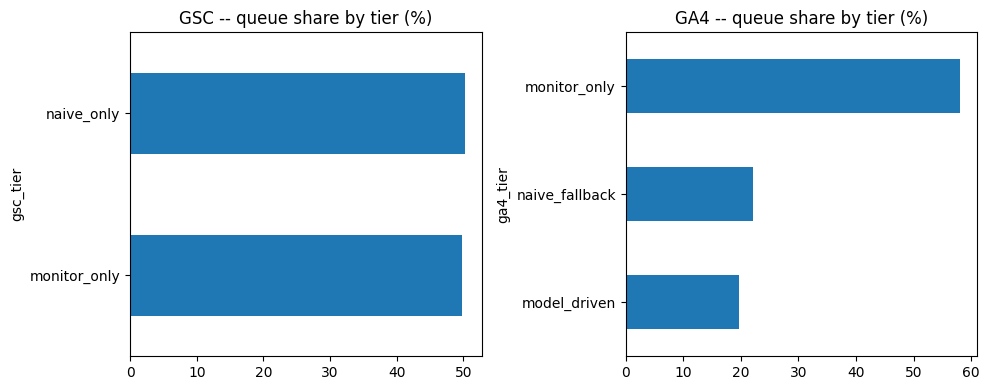

Wrote work/outputs/action_queue.csv (304,706 rows), work/outputs/queue_summary.csv, and work/outputs/reason_code_breakdown.png

Contents of ./work/outputs/:
total 113512
-rw-r--r-- 1 root root 116187603 Sep  1 18:09 action_queue.csv
-rw-r--r-- 1 root root       119 Sep  1 18:09 queue_summary.csv
-rw-r--r-- 1 root root     39637 Sep  1 18:09 reason_code_breakdown.png
Updated Git hooks.
Git LFS initialized.
"work/outputs/action_queue.csv" already supported

Git status after adding files:
On branch main
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   work/outputs/action_queue.csv
	new file:   work/outputs/queue_summary.csv

[main b6f75f2] Add generated output files and plots
 2 files changed, 8 insertions(+)
 create mode 100644 work/outputs/action_queue.csv
 create mode 100644 work/outputs/queue_summary.csv
Uploading LFS objects: 100% (1/1), 116 MB | 7.0 MB/s, done.
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compressio

In [51]:
import matplotlib.pyplot as plt
from pathlib import Path
import os

# Configure Git (these are global, set once per session)
!git config --global user.email "kurowa.jp@gmail.com"
!git config --global user.name "ku-ro-wa"

# Ensure we are in a clean and accessible directory for cloning
%cd /content/

# Clean up any previous, potentially nested, Git repository clones
!rm -rf flyrank-ml-starter # Remove only the cloned directory if it exists
# We avoid removing /content/.git as it might interfere with the current shell's state.

# Clone the repository into the expected path
# This should create /content/flyrank-ml-starter
!git clone https://github.com/ku-ro-wa/flyrank-ml-starter.git flyrank-ml-starter

# Change directory into the cloned repository
%cd flyrank-ml-starter

# Get the GitHub PAT from Colab secrets
from google.colab import userdata
GH_TOKEN = userdata.get('GH_TOKEN')

# Remove existing remote 'origin' if it exists, then add with PAT for authentication
!git remote remove origin || true
!git remote add origin https://{GH_TOKEN}@github.com/ku-ro-wa/flyrank-ml-starter.git

# Ensure the target outputs/ directory exists within the repo's 'work' folder
!mkdir -p ./work/outputs/

# --- BEGIN: Moved content from hiA_HCt6g06k ---
# Explicitly set the output directory relative to the current working directory (flyrank-ml-starter/)
sibling_dir = Path("./work") / "outputs"
sibling_dir.mkdir(exist_ok=True)

action_queue.to_csv(sibling_dir / "action_queue.csv", index=False)

queue_summary = pd.concat(
    {"gsc_tier_share_pct": gsc_tier_share, "ga4_tier_share_pct": ga4_tier_share}, axis=1
)
queue_summary.to_csv(sibling_dir / "queue_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
gsc_tier_share.sort_values().plot.barh(ax=axes[0], title="GSC -- queue share by tier (%)")
ga4_tier_share.sort_values().plot.barh(ax=axes[1], title="GA4 -- queue share by tier (%)")
fig.tight_layout()
fig.savefig(sibling_dir / "reason_code_breakdown.png", dpi=150)
plt.show()
plt.close(fig) # Close the figure to free up memory

print(f"Wrote {sibling_dir}/action_queue.csv ({len(action_queue):,} rows), "
      f"{sibling_dir}/queue_summary.csv, and {sibling_dir}/reason_code_breakdown.png")
# --- END: Moved content from hiA_HCt6g06k ---

# Verify contents of ./work/outputs/ (files should now be there)
print("\nContents of ./work/outputs/:")
!ls -l ./work/outputs/

# Add Git LFS setup and track the large CSV
!git lfs install
!git lfs track "work/outputs/action_queue.csv"

# Stage the .gitattributes file (created/modified by git lfs track)
!git add .gitattributes

# Stage the generated output files, explicitly forcing for ignored files
!git add -f work/outputs/action_queue.csv
!git add -f work/outputs/queue_summary.csv
!git add -f work/outputs/reason_code_breakdown.png

# Check git status after adding files
print("\nGit status after adding files:")
!git status

# Commit the changes
!git commit -m "Add generated output files and plots"

# Push the changes to GitHub
!git push origin main

Writes the full queue (`action_queue.csv` — one row per content item with predictions, tiers, and reason codes for both targets), the tier-share summary tables from §2 (`queue_summary.csv`), and one reusable figure (`reason_code_breakdown.png`) — the queue-share-by-tier bars are the number most likely to get reused as-is in a written report, since they're the concrete evidence behind the §2 limits claims. `outputs/` sits alongside the `warehouse/` and `data/` directories this notebook's own Section 0 already creates in the Colab session.

#Summary
 This queue serves exactly the two models `model_training.ipynb` Section 13 recommends — `BlendedModel` for GA4 sessions, `NaiveModel` alone for GSC clicks — and nothing more.

 GA4's model-driven tier is real (Section 0's rebuild reproduces Section 13's documented numbers), but only inside the buckets the router actually routed to the model; everywhere else, and for GSC entirely, the ranking is naive/momentum-ordered, not model skill.

 The near-zero-activity tier — the majority of any snapshot, per Section 9 — is always monitor-only regardless of predicted value, no matter how it sorts. Treat this as a weekly-refreshed priority list for a person to work from, not a standalone decision system: see Section 2 for what it doesn't cover, Section 3 for what a person must check before acting on it, and Section 4 for when to stop trusting it without a refit.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.